<a href="https://colab.research.google.com/github/kalyankargouri/Deep-Learning/blob/main/DLexper8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from lime import lime_tabular

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9139 - loss: 0.3036
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9568 - loss: 0.1476
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9680 - loss: 0.1074
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


  0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━

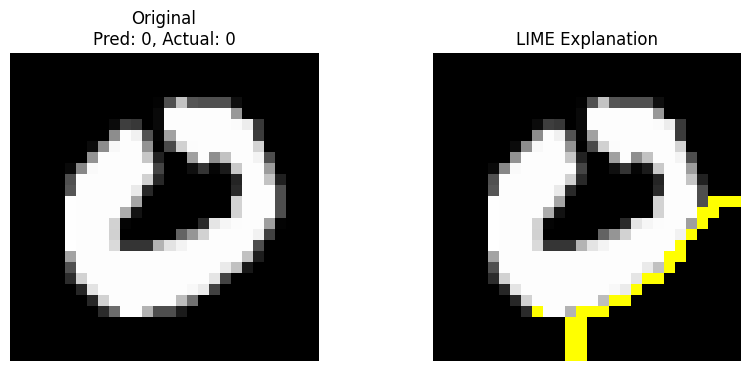


Observation Table:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Sample 0 → Predicted: 7, Actual: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Sample 1 → Predicted: 2, Actual: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Sample 2 → Predicted: 1, Actual: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Sample 3 → Predicted: 0, Actual: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Sample 4 → Predicted: 4, Actual: 4


In [3]:
# Install
!pip install lime -q

# -------------------------------
# 1. Import Libraries
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

from lime import lime_image
from skimage.segmentation import mark_boundaries

# -------------------------------
# 2. Load Dataset
# -------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)

# -------------------------------
# 3. Build Model
# -------------------------------
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3, verbose=1)

# -------------------------------
# 4. Prediction Function (FIXED)
# -------------------------------
def predict_fn(images):
    if len(images.shape) == 4 and images.shape[-1] == 3:
        images = np.mean(images, axis=-1)

    images = images.reshape(images.shape[0], 28, 28)
    return model.predict(images)

# -------------------------------
# 5. Select Different Image
# -------------------------------
index = 25   # ✅ changed image here
image = x_test[index]

# Prediction
pred = np.argmax(model.predict(image.reshape(1, 28, 28)))
actual = y_test[index]

# -------------------------------
# 6. Apply LIME
# -------------------------------
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image,
    predict_fn,
    top_labels=1,
    num_samples=500
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

# -------------------------------
# 7. Show Results (Better View)
# -------------------------------
plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title(f"Original\nPred: {pred}, Actual: {actual}")
plt.axis('off')

# LIME Explanation
plt.subplot(1,2,2)
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis('off')

plt.show()

# -------------------------------
# 8. Observation Table
# -------------------------------
print("\nObservation Table:\n")

for i in range(5):
    p = np.argmax(model.predict(x_test[i].reshape(1,28,28)))
    print(f"Sample {i} → Predicted: {p}, Actual: {y_test[i]}")